# Square Extraction from Warped Chess Boards

**Goal:** Extract 64 individual square crops (8x8 grid) from each warped board image.

**Pipeline:**
1. Load warped board images (800x800) from configurable input base
2. Divide each board into 8x8 grid (100x100 pixels per square)
3. Extract and save 64 squares per board
4. Generate metadata CSV with square information
5. Create debug visualizations for verification

**Input Sources:**
- Default: `data/processed/warped_unet/` (UNet-based geometry - **PRIMARY**)
- Alternative: `data/processed/warped_boardcoords/` (JSON-based geometry - experimental/deprecated)

In [ ]:
# Standard imports
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set up paths (relative paths from workspace root)
possible_roots = [
    Path.cwd().parent,  # If running from notebooks/ directory
    Path.cwd(),         # If running from workspace root
]

PROJECT_ROOT = None
for root in possible_roots:
    test_path = root / "data" / "processed" / "warped_unet"
    if test_path.exists() or (root / "data" / "processed" / "warped_boardcoords").exists():
        PROJECT_ROOT = root
        break

if PROJECT_ROOT is None:
    PROJECT_ROOT = Path.cwd()

# ===== CONFIGURABLE INPUT BASE =====
# PRIMARY: Use UNet-based warping (production pipeline)
# Alternative: Use JSON-based warping (experimental/deprecated)
INPUT_SOURCE = "unet"  # Options: "unet" (default) or "boardcoords"

if INPUT_SOURCE == "unet":
    WARPED_BASE = PROJECT_ROOT / "data" / "processed" / "warped_unet"
    SQUARES_BASE = PROJECT_ROOT / "data" / "processed" / "squares_unet"
elif INPUT_SOURCE == "boardcoords":
    WARPED_BASE = PROJECT_ROOT / "data" / "processed" / "warped_boardcoords"
    SQUARES_BASE = PROJECT_ROOT / "data" / "processed" / "squares_boardcoords"
else:
    raise ValueError(f"Invalid INPUT_SOURCE: {INPUT_SOURCE}. Use 'unet' or 'boardcoords'")

# Constants
BOARD_SIZE = 800  # Warped board size (800x800)
GRID_SIZE = 8     # 8x8 chess board
SQUARE_SIZE = BOARD_SIZE // GRID_SIZE  # 100 pixels per square

print(f"Project root: {PROJECT_ROOT}")
print(f"Warped images base: {WARPED_BASE}")
print(f"Squares output base: {SQUARES_BASE}")
print(f"\nBoard size: {BOARD_SIZE}x{BOARD_SIZE}")
print(f"Grid size: {GRID_SIZE}x{GRID_SIZE}")
print(f"Square size: {SQUARE_SIZE}x{SQUARE_SIZE} pixels")

Project root: /Users/ibrahimcbc/Library/CloudStorage/GoogleDrive-icebecioglu21@ku.edu.tr/My Drive/COMP411/assignments/COMP-411_Project/chessvision
Warped images base: /Users/ibrahimcbc/Library/CloudStorage/GoogleDrive-icebecioglu21@ku.edu.tr/My Drive/COMP411/assignments/COMP-411_Project/chessvision/data/processed/warped_unet
Squares output base: /Users/ibrahimcbc/Library/CloudStorage/GoogleDrive-icebecioglu21@ku.edu.tr/My Drive/COMP411/assignments/COMP-411_Project/chessvision/data/processed/squares_unet

Board size: 800x800
Grid size: 8x8
Square size: 100x100 pixels


## Helper Functions

In [ ]:
def row_col_to_chess_notation(row, col):
    """
    Convert grid position (row, col) to chess notation (a1-h8).
    Row 0 = rank 8 (top), Row 7 = rank 1 (bottom)
    Col 0 = file a (left), Col 7 = file h (right)
    """
    file_letter = chr(ord('a') + col)
    rank_number = 8 - row  # Row 0 -> rank 8, row 7 -> rank 1
    return f"{file_letter}{rank_number}"

def extract_square(board_image, row, col, square_size=100):
    """
    Extract a single square from the board image.

    Args:
        board_image: 800x800 warped board image (numpy array)
        row: Row index (0-7)
        col: Column index (0-7)
        square_size: Size of each square (default: 100)

    Returns:
        Square crop as numpy array (square_size x square_size)
    """
    y_start = row * square_size
    y_end = y_start + square_size
    x_start = col * square_size
    x_end = x_start + square_size

    square = board_image[y_start:y_end, x_start:x_end]
    return square

def draw_grid_with_indices(board_image, square_size=100, grid_size=8):
    """
    Draw 8x8 grid on board image with row/col indices.

    Returns:
        Image with grid overlay and labels
    """
    img_with_grid = board_image.copy()
    h, w = board_image.shape[:2]

    # Draw grid lines
    for i in range(grid_size + 1):
        # Vertical lines
        x = i * square_size
        cv2.line(img_with_grid, (x, 0), (x, h), (255, 0, 0), 2)
        # Horizontal lines
        y = i * square_size
        cv2.line(img_with_grid, (0, y), (w, y), (255, 0, 0), 2)

    # Add row/col labels
    for row in range(grid_size):
        for col in range(grid_size):
            # Calculate center of square
            center_x = col * square_size + square_size // 2
            center_y = row * square_size + square_size // 2

            # Label format: "r<row>_c<col>"
            label = f"r{row}_c{col}"

            # Get text size for centering
            font = cv2.FONT_HERSHEY_SIMPLEX
            font_scale = 0.4
            thickness = 1
            (text_width, text_height), baseline = cv2.getTextSize(label, font, font_scale, thickness)

            # Draw text background
            text_x = center_x - text_width // 2
            text_y = center_y + text_height // 2
            cv2.rectangle(img_with_grid,
                         (text_x - 2, text_y - text_height - 2),
                         (text_x + text_width + 2, text_y + baseline + 2),
                         (255, 255, 255), -1)

            # Draw text
            cv2.putText(img_with_grid, label, (text_x, text_y),
                       font, font_scale, (0, 0, 255), thickness)

    return img_with_grid

## Main Processing Function

In [ ]:
def process_split(split_name, debug_n=6):
    """
    Process all warped board images in a split to extract squares.

    Args:
        split_name: Split name ('train', 'validation', 'test')
        debug_n: Number of boards to generate debug outputs for

    Returns:
        Dictionary with statistics
    """
    print(f"\n{'='*60}")
    print(f"Processing {split_name} split")
    print(f"{'='*60}")

    # Set up paths
    warped_images_dir = WARPED_BASE / split_name / "images"
    squares_images_dir = SQUARES_BASE / split_name / "images"
    squares_debug_dir = SQUARES_BASE / split_name / "debug"
    metadata_path = SQUARES_BASE / split_name / "squares_metadata.csv"

    # Create output directories
    squares_images_dir.mkdir(parents=True, exist_ok=True)
    squares_debug_dir.mkdir(parents=True, exist_ok=True)

    # Get all warped board images
    board_images = sorted(list(warped_images_dir.glob("*.png")))
    print(f"Found {len(board_images)} warped board images")

    # Statistics
    stats = {
        'total_boards': len(board_images),
        'total_squares': 0,
        'squares_saved': 0,
        'debug_outputs': 0
    }

    # Metadata list
    metadata_rows = []

    for idx, board_path in enumerate(board_images):
        board_stem = board_path.stem

        # Load warped board image
        board_image = cv2.imread(str(board_path))
        if board_image is None:
            print(f"⚠️ Could not load image: {board_path.name}")
            continue

        # Convert BGR to RGB for processing
        board_image_rgb = cv2.cvtColor(board_image, cv2.COLOR_BGR2RGB)
        h, w = board_image_rgb.shape[:2]

        # Verify image size
        if h != BOARD_SIZE or w != BOARD_SIZE:
            print(f"⚠️ Image {board_path.name} has size {w}x{h}, expected {BOARD_SIZE}x{BOARD_SIZE}")
            continue

        # Extract all 64 squares
        for row in range(GRID_SIZE):
            for col in range(GRID_SIZE):
                # Extract square
                square = extract_square(board_image_rgb, row, col, SQUARE_SIZE)

                # Verify square size
                if square.shape[0] != SQUARE_SIZE or square.shape[1] != SQUARE_SIZE:
                    print(f"⚠️ Square r{row}_c{col} from {board_stem} has wrong size: {square.shape}")
                    continue

                # Generate square filename
                square_filename = f"{board_stem}_r{row}_c{col}.png"
                square_path = squares_images_dir / square_filename

                # Convert RGB back to BGR for saving
                square_bgr = cv2.cvtColor(square, cv2.COLOR_RGB2BGR)
                cv2.imwrite(str(square_path), square_bgr)

                stats['squares_saved'] += 1

                # Add to metadata
                chess_notation = row_col_to_chess_notation(row, col)
                metadata_rows.append({
                    'board_stem': board_stem,
                    'split': split_name,
                    'row': row,
                    'col': col,
                    'chess_notation': chess_notation,
                    'square_filename': square_filename
                })

        stats['total_squares'] += 64

        # Debug outputs for first N boards
        if idx < debug_n:
            # A) Grid visualization with indices
            grid_image = draw_grid_with_indices(board_image_rgb.copy(), SQUARE_SIZE, GRID_SIZE)
            grid_image_bgr = cv2.cvtColor(grid_image, cv2.COLOR_RGB2BGR)
            grid_debug_path = squares_debug_dir / f"{board_stem}_grid_index.png"
            cv2.imwrite(str(grid_debug_path), grid_image_bgr)

            # B) 3x3 montage of selected squares (corners + center)
            selected_squares = [
                (0, 0),   # Top-left
                (0, 7),   # Top-right
                (3, 3),   # Center
                (3, 4),   # Center-right
                (7, 0),   # Bottom-left
                (7, 7),   # Bottom-right
                (1, 1),   # Near top-left
                (6, 6),   # Near bottom-right
                (4, 4),   # Center area
            ]

            # Create 3x3 montage
            fig, axes = plt.subplots(3, 3, figsize=(9, 9))
            for i, (row, col) in enumerate(selected_squares):
                square = extract_square(board_image_rgb, row, col, SQUARE_SIZE)
                ax = axes[i // 3, i % 3]
                ax.imshow(square)
                ax.set_title(f"r{row}_c{col}\n{row_col_to_chess_notation(row, col)}", fontsize=8)
                ax.axis('off')

            plt.suptitle(f"Square Montage - {board_stem}", fontsize=10, fontweight='bold')
            plt.tight_layout()

            montage_path = squares_debug_dir / f"{board_stem}_squares_montage.png"
            plt.savefig(montage_path, dpi=150, bbox_inches='tight')
            plt.close()

            stats['debug_outputs'] += 1

        if (idx + 1) % 20 == 0:
            print(f"  Processed {idx + 1}/{len(board_images)} boards...")

    # Save metadata CSV
    if len(metadata_rows) > 0:
        df_metadata = pd.DataFrame(metadata_rows)
        df_metadata.to_csv(metadata_path, index=False)
        print(f"✓ Saved metadata to: {metadata_path}")
        print(f"  Metadata rows: {len(metadata_rows)}")

    return stats

## Process All Splits

In [ ]:
# Process all splits
all_stats = {}

for split_name in ['train', 'validation', 'test']:
    warped_dir = WARPED_BASE / split_name / "images"
    if warped_dir.exists() and len(list(warped_dir.glob("*.png"))) > 0:
        stats = process_split(split_name, debug_n=6)
        all_stats[split_name] = stats
    else:
        print(f"\n⚠️ No warped images found for {split_name} split, skipping...")


Processing train split
Found 129 warped board images
  Processed 20/129 boards...
  Processed 40/129 boards...
  Processed 60/129 boards...
  Processed 80/129 boards...
  Processed 100/129 boards...
  Processed 120/129 boards...
✓ Saved metadata to: /Users/ibrahimcbc/Library/CloudStorage/GoogleDrive-icebecioglu21@ku.edu.tr/My Drive/COMP411/assignments/COMP-411_Project/chessvision/data/processed/squares_unet/train/squares_metadata.csv
  Metadata rows: 8256

Processing validation split
Found 42 warped board images
  Processed 20/42 boards...
  Processed 40/42 boards...
✓ Saved metadata to: /Users/ibrahimcbc/Library/CloudStorage/GoogleDrive-icebecioglu21@ku.edu.tr/My Drive/COMP411/assignments/COMP-411_Project/chessvision/data/processed/squares_unet/validation/squares_metadata.csv
  Metadata rows: 2688

Processing test split
Found 43 warped board images
  Processed 20/43 boards...
  Processed 40/43 boards...
✓ Saved metadata to: /Users/ibrahimcbc/Library/CloudStorage/GoogleDrive-icebeciog

## Summary Statistics

In [ ]:
# Print comprehensive summary
print("\n" + "="*80)
print("SQUARE EXTRACTION SUMMARY")
print("="*80)

total_all = {
    'total_boards': 0,
    'total_squares': 0,
    'squares_saved': 0,
    'debug_outputs': 0
}

for split_name in ['train', 'validation', 'test']:
    if split_name in all_stats:
        stats = all_stats[split_name]
        print(f"\n{split_name.upper()} SPLIT:")
        print(f"  Total boards processed:    {stats['total_boards']}")
        print(f"  Expected squares (64x):    {stats['total_boards'] * 64}")
        print(f"  Squares saved:             {stats['squares_saved']}")
        print(f"  Debug outputs generated:   {stats['debug_outputs']}")

        # Verify square size
        squares_dir = SQUARES_BASE / split_name / "images"
        if squares_dir.exists():
            sample_squares = list(squares_dir.glob("*.png"))[:5]
            if len(sample_squares) > 0:
                sample_img = cv2.imread(str(sample_squares[0]))
                if sample_img is not None:
                    h, w = sample_img.shape[:2]
                    print(f"  Square image size:         {w}x{h} pixels")
                    if w == SQUARE_SIZE and h == SQUARE_SIZE:
                        print(f"  ✓ Square size correct ({SQUARE_SIZE}x{SQUARE_SIZE})")
                    else:
                        print(f"  ⚠️ Square size mismatch! Expected {SQUARE_SIZE}x{SQUARE_SIZE}")

        # Check metadata
        metadata_path = SQUARES_BASE / split_name / "squares_metadata.csv"
        if metadata_path.exists():
            df = pd.read_csv(metadata_path)
            print(f"  Metadata CSV rows:         {len(df)}")

        print(f"\n  Output directories:")
        print(f"    Squares:  {SQUARES_BASE / split_name / 'images'}")
        print(f"    Debug:    {SQUARES_BASE / split_name / 'debug'}")
        print(f"    Metadata: {SQUARES_BASE / split_name / 'squares_metadata.csv'}")

        # Accumulate totals
        total_all['total_boards'] += stats['total_boards']
        total_all['total_squares'] += stats['total_squares']
        total_all['squares_saved'] += stats['squares_saved']
        total_all['debug_outputs'] += stats['debug_outputs']

print("\n" + "="*80)
print("TOTALS (ALL SPLITS):")
print("="*80)
print(f"  Total boards processed:    {total_all['total_boards']}")
print(f"  Expected squares (64x):    {total_all['total_boards'] * 64}")
print(f"  Squares saved:             {total_all['squares_saved']}")
print(f"  Debug outputs:             {total_all['debug_outputs']}")

if total_all['total_boards'] > 0:
    expected_squares = total_all['total_boards'] * 64
    if total_all['squares_saved'] == expected_squares:
        print(f"  ✓ All squares extracted successfully!")
    else:
        print(f"  ⚠️ Mismatch: Expected {expected_squares}, saved {total_all['squares_saved']}")

print("\n" + "="*80)
print("✓ Square extraction complete!")
print("="*80)


SQUARE EXTRACTION SUMMARY

TRAIN SPLIT:
  Total boards processed:    129
  Expected squares (64x):    8256
  Squares saved:             8256
  Debug outputs generated:   6
  Square image size:         100x100 pixels
  ✓ Square size correct (100x100)
  Metadata CSV rows:         8256

  Output directories:
    Squares:  /Users/ibrahimcbc/Library/CloudStorage/GoogleDrive-icebecioglu21@ku.edu.tr/My Drive/COMP411/assignments/COMP-411_Project/chessvision/data/processed/squares_unet/train/images
    Debug:    /Users/ibrahimcbc/Library/CloudStorage/GoogleDrive-icebecioglu21@ku.edu.tr/My Drive/COMP411/assignments/COMP-411_Project/chessvision/data/processed/squares_unet/train/debug
    Metadata: /Users/ibrahimcbc/Library/CloudStorage/GoogleDrive-icebecioglu21@ku.edu.tr/My Drive/COMP411/assignments/COMP-411_Project/chessvision/data/processed/squares_unet/train/squares_metadata.csv

VALIDATION SPLIT:
  Total boards processed:    42
  Expected squares (64x):    2688
  Squares saved:             2

## Visual Demo: Square Extraction Pipeline

**Goal:** Create a visual demonstration of the square extraction step using the same example board from the warp demo.

**Outputs:**
1. Warped image with grid + square indices
2. Montage of 9 square crops (corners + center)

In [ ]:
# Visual Demo: Use the same board from warp demo
DEMOS_BASE = PROJECT_ROOT / "data" / "processed" / "demos"
DEMOS_BASE.mkdir(parents=True, exist_ok=True)

# Load the warped image (from the warp demo - should exist if warp demo was run)
# We'll use the first warped image from train split
warped_images_dir = WARPED_BASE / "train" / "images"
warped_image_files = sorted(list(warped_images_dir.glob("*.png")))

if len(warped_image_files) == 0:
    raise ValueError("No warped images found! Please run the warp pipeline first.")

# Use the first warped image
warped_image_path = warped_image_files[0]
board_stem = warped_image_path.stem

print(f"✓ Selected board: {board_stem}")
print(f"  Warped image path: {warped_image_path}")

# Load warped image
warped_image = cv2.imread(str(warped_image_path))
if warped_image is None:
    raise ValueError(f"Failed to load warped image: {warped_image_path}")

warped_image_rgb = cv2.cvtColor(warped_image, cv2.COLOR_BGR2RGB)
h, w = warped_image_rgb.shape[:2]
print(f"  Warped image size: {w}x{h}")

# Verify size
if w != BOARD_SIZE or h != BOARD_SIZE:
    print(f"⚠️ Warning: Expected {BOARD_SIZE}x{BOARD_SIZE}, got {w}x{h}")
else:
    print(f"  ✓ Image size correct ({BOARD_SIZE}x{BOARD_SIZE})")

✓ Selected board: 00bc0cacffdebe6b11bdeec56f63ee49_jpg.rf.1a1407058a6170f001f2c269411d31d3
  Warped image path: /Users/ibrahimcbc/Library/CloudStorage/GoogleDrive-icebecioglu21@ku.edu.tr/My Drive/COMP411/assignments/COMP-411_Project/chessvision/data/processed/warped_unet/train/images/00bc0cacffdebe6b11bdeec56f63ee49_jpg.rf.1a1407058a6170f001f2c269411d31d3.png
  Warped image size: 800x800
  ✓ Image size correct (800x800)


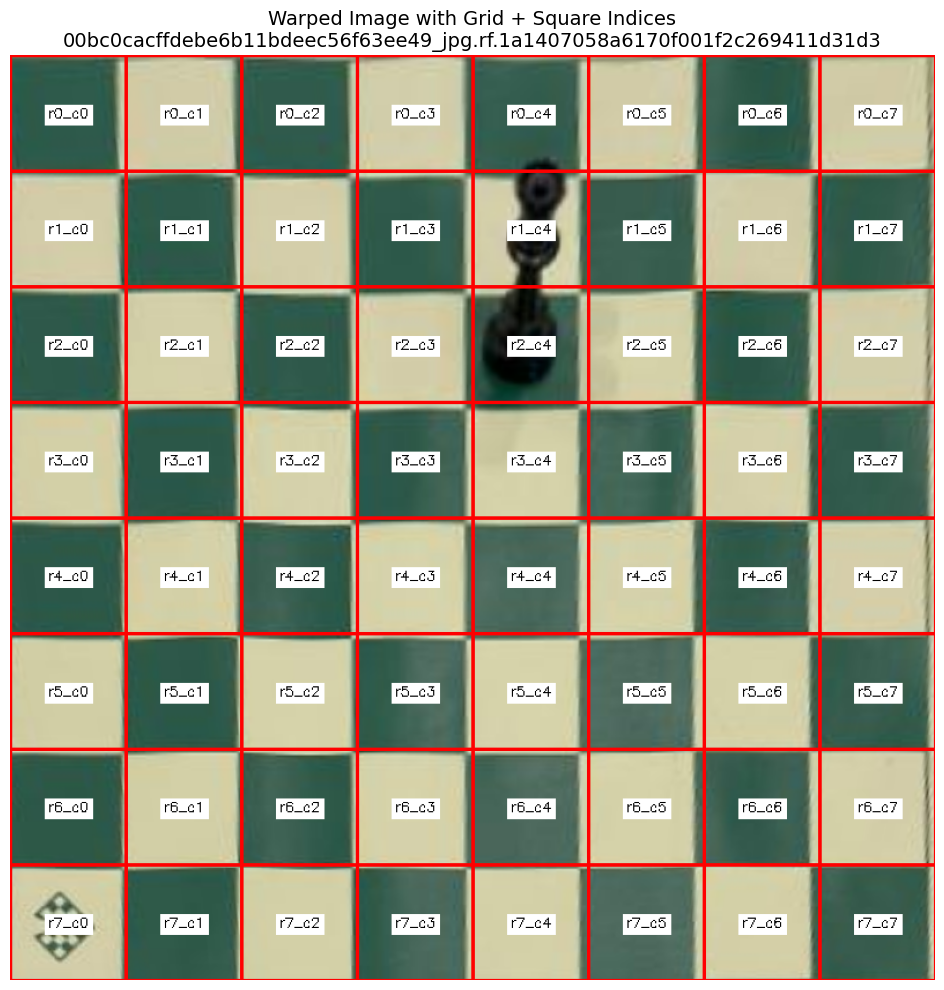

✓ Saved: demo_grid_index.png


In [ ]:
# 4) Warped image with grid + square indices
img_with_indices = warped_image_rgb.copy()

# Draw grid lines
for i in range(GRID_SIZE + 1):
    x = i * SQUARE_SIZE
    cv2.line(img_with_indices, (x, 0), (x, BOARD_SIZE), (255, 0, 0), 2)
    y = i * SQUARE_SIZE
    cv2.line(img_with_indices, (0, y), (BOARD_SIZE, y), (255, 0, 0), 2)

# Add row/col labels
for row in range(GRID_SIZE):
    for col in range(GRID_SIZE):
        center_x = col * SQUARE_SIZE + SQUARE_SIZE // 2
        center_y = row * SQUARE_SIZE + SQUARE_SIZE // 2
        label = f"r{row}_c{col}"
        font = cv2.FONT_HERSHEY_SIMPLEX
        font_scale = 0.4
        thickness = 1
        (text_width, text_height), baseline = cv2.getTextSize(label, font, font_scale, thickness)
        text_x = center_x - text_width // 2
        text_y = center_y + text_height // 2
        cv2.rectangle(img_with_indices,
                      (text_x - 2, text_y - text_height - 2),
                      (text_x + text_width + 2, text_y + baseline + 2),
                      (255, 255, 255), -1)
        cv2.putText(img_with_indices, label, (text_x, text_y),
                   font, font_scale, (0, 0, 0), thickness)

plt.figure(figsize=(10, 10))
plt.imshow(img_with_indices)
plt.title(f"Warped Image with Grid + Square Indices\n{board_stem}", fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.savefig(DEMOS_BASE / "demo_grid_index.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved: demo_grid_index.png")

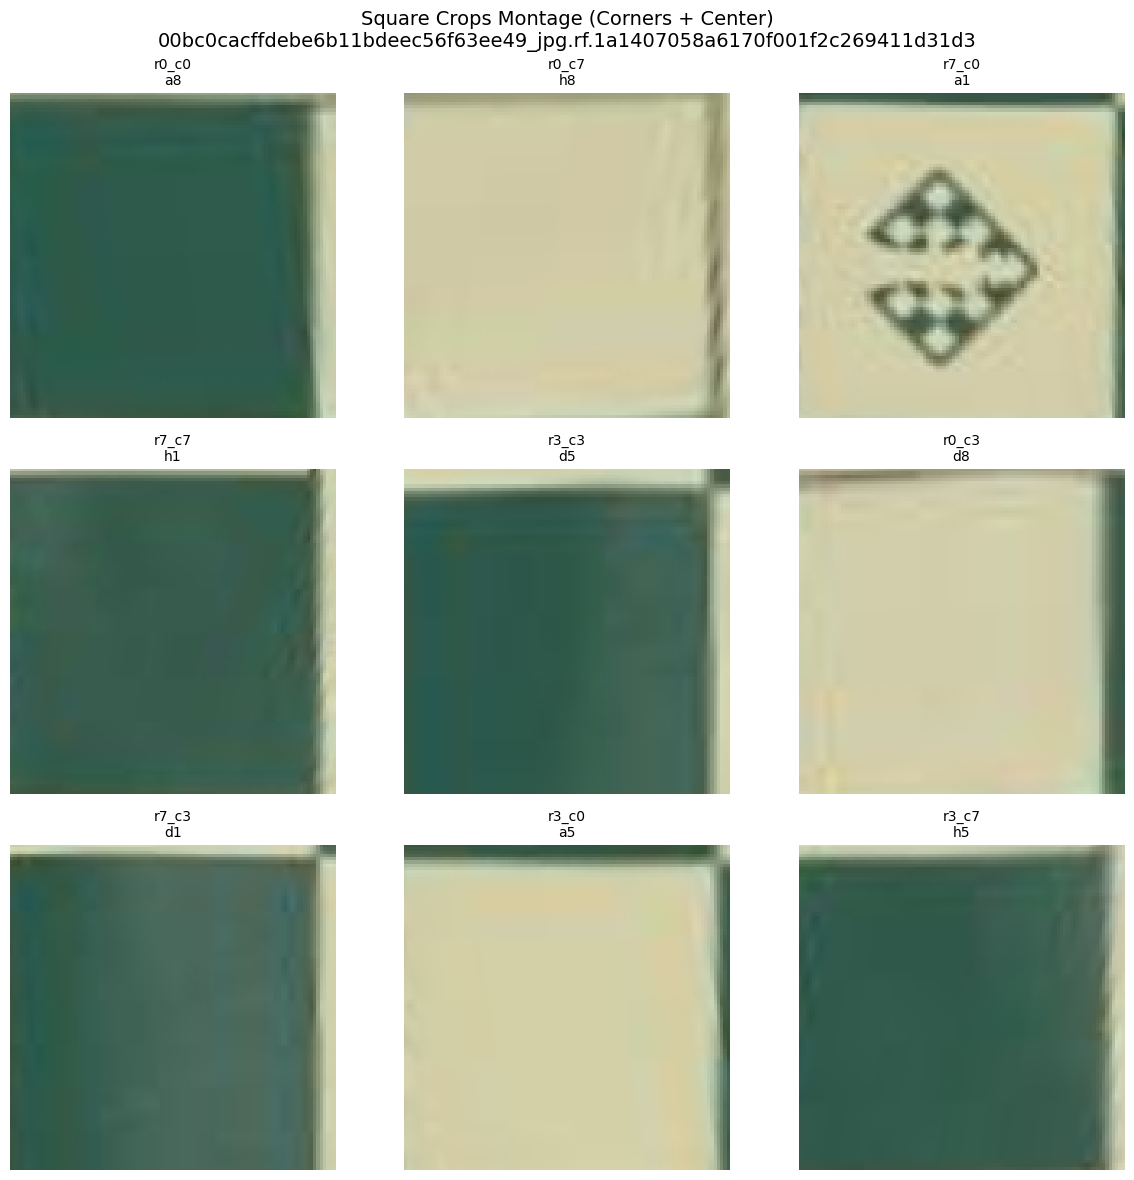

✓ Saved: demo_squares_montage.png


In [ ]:
# 5) Montage of 9 square crops (corners + center)
# Select squares: 4 corners + center + 4 edge centers
selected_squares = [
    (0, 0, 'a8'),      # Top-left
    (0, 7, 'h8'),      # Top-right
    (7, 0, 'a1'),      # Bottom-left
    (7, 7, 'h1'),      # Bottom-right
    (3, 3, 'd5'),      # Center
    (0, 3, 'd8'),      # Top-center
    (7, 3, 'd1'),      # Bottom-center
    (3, 0, 'a5'),      # Left-center
    (3, 7, 'h5'),      # Right-center
]

# Extract squares
square_images = []
square_labels = []
for row, col, chess_notation in selected_squares:
    square = extract_square(warped_image_rgb, row, col, SQUARE_SIZE)
    square_images.append(square)
    square_labels.append(f"r{row}_c{col}\n{chess_notation}")

# Create 3x3 montage
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten()

for idx, (img, label) in enumerate(zip(square_images, square_labels)):
    axes[idx].imshow(img)
    axes[idx].set_title(label, fontsize=10)
    axes[idx].axis('off')

plt.suptitle(f"Square Crops Montage (Corners + Center)\n{board_stem}", fontsize=14)
plt.tight_layout()
plt.savefig(DEMOS_BASE / "demo_squares_montage.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved: demo_squares_montage.png")

In [ ]:
# Demo Summary
print("\n" + "="*80)
print("VISUAL DEMO SUMMARY")
print("="*80)
print(f"\nBoard used: {board_stem}")
print(f"\nSquare size verification:")
print(f"  Expected: {SQUARE_SIZE}x{SQUARE_SIZE} pixels")
if len(square_images) > 0:
    sample_square = square_images[0]
    sh, sw = sample_square.shape[:2]
    print(f"  Actual:   {sw}x{sh} pixels")
    if sw == SQUARE_SIZE and sh == SQUARE_SIZE:
        print(f"  ✓ Square size correct!")
    else:
        print(f"  ⚠️ Square size mismatch!")

print(f"\nChess notation mapping examples:")
print(f"  Row 0, Col 0 (r0_c0) → {row_col_to_chess_notation(0, 0)}  (top-left)")
print(f"  Row 0, Col 7 (r0_c7) → {row_col_to_chess_notation(0, 7)}  (top-right)")
print(f"  Row 7, Col 0 (r7_c0) → {row_col_to_chess_notation(7, 0)}  (bottom-left)")
print(f"  Row 7, Col 7 (r7_c7) → {row_col_to_chess_notation(7, 7)}  (bottom-right)")
print(f"  Row 3, Col 3 (r3_c3) → {row_col_to_chess_notation(3, 3)}  (center)")

print(f"\nDemo outputs saved to: {DEMOS_BASE}")
print("="*80)


VISUAL DEMO SUMMARY

Board used: 00bc0cacffdebe6b11bdeec56f63ee49_jpg.rf.1a1407058a6170f001f2c269411d31d3

Square size verification:
  Expected: 100x100 pixels
  Actual:   100x100 pixels
  ✓ Square size correct!

Chess notation mapping examples:
  Row 0, Col 0 (r0_c0) → a8  (top-left)
  Row 0, Col 7 (r0_c7) → h8  (top-right)
  Row 7, Col 0 (r7_c0) → a1  (bottom-left)
  Row 7, Col 7 (r7_c7) → h1  (bottom-right)
  Row 3, Col 3 (r3_c3) → d5  (center)

Demo outputs saved to: /Users/ibrahimcbc/Library/CloudStorage/GoogleDrive-icebecioglu21@ku.edu.tr/My Drive/COMP411/assignments/COMP-411_Project/chessvision/data/processed/demos
